# 🧠 Building a Mini GPT from Scratch using PyTorch

Welcome to my implementation of a **miniature GPT (Generative Pretrained Transformer)** — built completely **from scratch** using **PyTorch** 🧩  

This notebook is not just code — it's a **learning journey** into how modern LLMs like **GPT** actually work under the hood.  
Every section is written with **clear explanations and detailed comments**, so even if you're new to deep learning or transformers, you'll understand how each piece connects — from token embeddings to self-attention to text generation.  

### 🌟 Why I Made This
As an AI developer, I wanted to **demystify the architecture** behind GPT and make it accessible for learners, while also showcasing how solid PyTorch fundamentals can lead to powerful results.  
Whether you’re an **HR**, **tech lead**, or an **aspiring data scientist**, this notebook demonstrates both **technical depth** and **clarity of thought** — a balance that defines great engineering.  

---

🔍 **Highlights of this Notebook**
- Implemented GPT-style transformer **from scratch** (no high-level shortcuts)  
- Detailed code comments for **beginner-to-advanced understanding**  
- Shows **attention mechanisms**, **multi-heads**, **feed-forward layers**, and **token embeddings**  
- Fully functional **text generation demo** at the end  
- Written for **learning, sharing, and showcasing real skills** 💪  

---

> 🌱 *If you're a student or beginner — go step by step, read the comments, and experiment.  
If you're a recruiter or AI professional — this reflects how I think, code, and explain AI systems clearly and deeply.*


# 🧠 Minimal GPT Architecture (Educational Example)

### 📝 Overview
This file demonstrates how to build a **simple GPT-like model** using PyTorch.  
We will gradually define each core component:
- **Embedding Layers** – Convert tokens into dense vectors.  
- **Self-Attention Mechanism** – Allow each token to attend to others.  
- **Transformer Blocks** – Stack multiple layers for deeper understanding.  
- **Language Modeling Head** – Predict the next token in a sequence.

---

### 🧩 Step 1: Import Required Libraries
PyTorch provides all the tools we need to build and train neural networks.

```python
# ------------------------------------------------------------
# Title: Minimal GPT Architecture (Educational Example)
# Author: Gourab Kumar
# ------------------------------------------------------------

# 1️⃣ Importing necessary PyTorch modules

# torch        → Core PyTorch library for tensor operations.
# torch.nn     → Provides neural network building blocks (layers, modules).
# torch.nn.functional (F) → Gives access to low-level functional APIs
#                         like activation functions and loss functions.

import torch
import torch.nn as nn
from torch.nn import functional as F


In [1]:
import torch
import torch.nn as nn
from torch.nn import functional as F

## ⚙️ Step 2: Define Hyperparameters

Hyperparameters control how our model learns and how large or deep it is.  
They are not learned during training — instead, we set them manually before training starts.

```python
# ------------------------------------------------------------
# Step 2: Define Hyperparameters
# ------------------------------------------------------------

# Number of sequences processed in parallel.
batch_size = 64  

# Maximum number of tokens (context length) the model can use to predict the next token.
block_size = 256  

# Total number of iterations (training steps).
max_iters = 5000  

# Evaluate the model performance after every few iterations.
eval_interval = 500  

# Learning rate controls how fast the model updates its parameters.
learning_rate = 3e-4  

# Automatically use GPU if available, else fall back to CPU.
device = 'cuda' if torch.cuda.is_available() else 'cpu'  

# Number of batches used to average evaluation metrics (for stable validation).
eval_iters = 200  

# Dimensionality of token embeddings (hidden size of each vector).
n_embd = 384  

# Number of attention heads in the multi-head attention mechanism.
n_head = 6  

# Number of transformer blocks (depth of the model).
n_layer = 6  

# Dropout probability — helps prevent overfitting by randomly disabling neurons.
dropout = 0.2  

# ------------------------------------------------------------


In [2]:
# hyperparameters
batch_size = 64 
block_size = 256
max_iters = 5000
eval_interval = 500
learning_rate = 3e-4
device = 'cuda' if torch.cuda.is_available() else 'cpu'
eval_iters = 200
n_embd = 384
n_head = 6
n_layer = 6
dropout = 0.2

## Notes

- **batch_size** → Controls how much data is processed at once.  
  Higher values require more GPU memory.

- **block_size** → Critical in GPT models.  
  Defines how many previous tokens the model can *“see”* when predicting the next one.

- **n_embd**, **n_head**, and **n_layer** → Together define overall model capacity.  
  (Small GPTs often use: 6 layers, 6 heads, 384 embeddings.)

- **dropout** → Helps the model generalize better during training.


## 🧩 Step 3: Set Random Seed for Reproducibility

To make sure our experiments are **reproducible**, we fix the random seed.  
PyTorch uses random numbers for tasks like weight initialization and data shuffling.  
If we don’t set a seed, every run will give slightly different results —  
but with a fixed seed, we can reproduce the exact same behavior each time.

```python
# ------------------------------------------------------------
# Step 3: Set Random Seed
# ------------------------------------------------------------

# Setting a fixed random seed ensures reproducibility.
# It helps us get consistent results across different runs of the same code.
torch.manual_seed(1337)
# ------------------------------------------------------------


In [3]:
torch.manual_seed(1337)

## Notes

- **torch.manual_seed()** → Ensures deterministic random number generation for both CPU and GPU operations.

- You can use any integer (e.g., 42, 1234), but using the **same seed value** guarantees identical results across runs.

- This is crucial when experimenting with **model architectures** or **hyperparameter tuning**, as it allows fair comparison between runs.


## 📚 Step 4: Load the Dataset (Tiny Shakespeare)

We'll use a small text dataset called **Tiny Shakespeare**,  
a collection of Shakespeare’s writings often used for character-level modeling.  
It’s only about 1 MB — perfect for quick experiments.

You can download it from GitHub using the command below (works in Linux/macOS terminals):

```bash
# Download the dataset (run this in your terminal or notebook cell)
wget https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt
Once downloaded, we open and read the entire text file into memory.



```python
# ------------------------------------------------------------
# Step 4: Load the Dataset
# ------------------------------------------------------------

# Open the text file containing Shakespeare’s writings.
# The file is read in UTF-8 encoding to support all characters.
with open('input.txt', 'r', encoding='utf-8') as f:
    text = f.read()

# The variable 'text' now contains the full dataset as a single string.
# Example: text[:1000] would show the first 1000 characters.
# ------------------------------------------------------------


In [4]:
import urllib.request

url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
urllib.request.urlretrieve(url, "input.txt")

print("Download complete!")


Download complete!


In [5]:
with open('input.txt', 'r', encoding='utf-8') as f:
    text = f.read()

## 🔡 Step 5: Building Vocabulary and Encoding Text

Now that we have our entire text dataset loaded,  
we need to **convert characters into numbers** — because neural networks can’t directly process text.  

We'll perform these steps:
1. Extract all unique characters in the dataset.  
2. Create a vocabulary (mapping between characters and integer indices).  
3. Define two helper functions:
   - `encode()` → Converts text → numbers  
   - `decode()` → Converts numbers → text  

---

```python
# ------------------------------------------------------------
# Step 5: Build Vocabulary and Encoding Logic
# ------------------------------------------------------------

# Get all unique characters present in the dataset
chars = sorted(list(set(text)))

# Count how many unique characters exist (vocabulary size)
vocab_size = len(chars)

# Create mapping dictionaries:
# stoi (string-to-index): maps each character to a unique integer
stoi = { ch:i for i,ch in enumerate(chars) }

# itos (index-to-string): reverse mapping, converts integers back to characters
itos = { i:ch for i,ch in enumerate(chars) }

# Encoder function: converts a string into a list of integers
encode = lambda s: [stoi[c] for c in s]

# Decoder function: converts a list of integers back into a string
decode = lambda l: ''.join([itos[i] for i in l])

# Example usage:
# sample = "hello"
# encoded = encode(sample)  # [indices...]
# decoded = decode(encoded) # "hello"
# ------------------------------------------------------------


In [6]:
chars = sorted(list(set(text)))
vocab_size = len(chars)
stoi = { ch:i for i,ch in enumerate(chars) }
itos = { i:ch for i,ch in enumerate(chars) }
encode = lambda s: [stoi[c] for c in s] 
decode = lambda l: ''.join([itos[i] for i in l]) 

## Notes

- **Vocabulary size (vocab_size)** → Number of unique symbols (characters) the model can predict.

- In the **Tiny Shakespeare dataset**, there are typically around **65–70 unique characters**.

- The **encoder–decoder pair** is fundamental:  
  - **encode()** → Converts human-readable text into model-understandable numbers.  
  - **decode()** → Converts model outputs back into readable text.

- This is a **character-level tokenization**, not word-level —  
  GPT learns language patterns by predicting **one character at a time**.


## 🧮 Step 6: Train–Validation Split

Once we’ve encoded the text into integers,  
we need to divide the data into two parts:

- **Training Set (90%)** → Used to train the model.  
- **Validation Set (10%)** → Used to measure how well the model generalizes to unseen data.

This helps us detect **overfitting** — when the model memorizes the training data instead of learning patterns.

---

```python
# ------------------------------------------------------------
# Step 6: Train and Validation Split
# ------------------------------------------------------------

# Convert the entire text (string) into a tensor of integers.
# Each character becomes an integer token.
data = torch.tensor(encode(text), dtype=torch.long)

# Determine split point (90% for training, 10% for validation)
n = int(0.9 * len(data))

# Split the data accordingly
train_data = data[:n]
val_data = data[n:]

# 'train_data' → used to learn the model parameters
# 'val_data'   → used to evaluate how well the model generalizes
# ------------------------------------------------------------


In [7]:
data = torch.tensor(encode(text), dtype=torch.long)
n = int(0.9*len(data)) 
train_data = data[:n]
val_data = data[n:]

## Notes

- **torch.tensor()** → Converts Python lists into PyTorch tensors,  
  making them ready for GPU processing and model training.

- **Why 90/10 split?**  
  - **Training data** → Provides patterns for the model to learn.  
  - **Validation data** → Checks if the model performs well on unseen text.

- **torch.long** → Used for tensors because tokens are integer indices,  
  which are required for **embedding layers** in PyTorch.


## 🧠 Step 7: Data Loading and Loss Estimation

Before training, we need a way to efficiently feed data into the model.  
Neural networks learn best when data is processed in **mini-batches**, not all at once.

We'll define two key functions:
1. `get_batch(split)` → Creates small random batches of input (`x`) and target (`y`) data.  
2. `estimate_loss()` → Evaluates the model’s average loss on both **training** and **validation** sets.

---

```python
# ------------------------------------------------------------
# Step 7: Data Loading and Loss Estimation
# ------------------------------------------------------------

# Function: Generate a small batch of training or validation data
def get_batch(split):
    """
    Creates a mini-batch of input (x) and target (y) sequences.
    Each batch consists of random chunks of the dataset.
    """
    # Choose which dataset to use
    data = train_data if split == 'train' else val_data

    # Random starting indices for each sequence in the batch
    ix = torch.randint(len(data) - block_size, (batch_size,))

    # Create input (x) and target (y) sequences:
    # - x: current block of tokens
    # - y: same block but shifted by one position (next-token prediction)
    x = torch.stack([data[i:i + block_size] for i in ix])
    y = torch.stack([data[i + 1:i + block_size + 1] for i in ix])

    # Move tensors to GPU (if available)
    x, y = x.to(device), y.to(device)
    return x, y


# ------------------------------------------------------------
# Function: Estimate average loss on train and validation sets
# ------------------------------------------------------------

@torch.no_grad()  # Disable gradient tracking for faster evaluation
def estimate_loss():
    """
    Computes the average loss over a few batches for both
    training and validation datasets.
    """
    out = {}
    model.eval()  # Set model to evaluation mode (disables dropout, etc.)

    for split in ['train', 'val']:
        losses = torch.zeros(eval_iters)
        for k in range(eval_iters):
            X, Y = get_batch(split)
            logits, loss = model(X, Y)
            losses[k] = loss.item()
        out[split] = losses.mean()

    model.train()  # Switch back to training mode
    return out
# ------------------------------------------------------------


In [8]:
def get_batch(split):
    data = train_data if split == 'train' else val_data
    ix = torch.randint(len(data) - block_size, (batch_size,))
    x = torch.stack([data[i:i+block_size] for i in ix])
    y = torch.stack([data[i+1:i+block_size+1] for i in ix])
    x, y = x.to(device), y.to(device)
    return x, y

@torch.no_grad()
def estimate_loss():
    out = {}
    model.eval()
    for split in ['train', 'val']:
        losses = torch.zeros(eval_iters)
        for k in range(eval_iters):
            X, Y = get_batch(split)
            logits, loss = model(X, Y)
            losses[k] = loss.item()
        out[split] = losses.mean()
    model.train()
    return out

## Notes

- **Mini-batches** → Improve training stability and make GPU computation efficient.

- **In `get_batch()`:**  
  - **x** → Input tokens  
  - **y** → Target tokens (shifted by 1)  
    → This teaches the model to **predict the next token** in a sequence.

- **@torch.no_grad()** → Temporarily disables gradient computation,  
  making evaluation **faster** and **more memory-efficient**.

- **model.eval()** and **model.train()** → Toggle between **evaluation** and **training** modes,  
  affecting layers like **Dropout** and **BatchNorm**.


## 🧩 Step 8: Building the Self-Attention Head

The **Self-Attention mechanism** allows each token in a sequence  
to look at (or “attend to”) other tokens to capture relationships and context.

In GPT models, each attention head performs the following:
1. Compute **Key (K)**, **Query (Q)**, and **Value (V)** vectors from the input.  
2. Measure *similarity* between queries and keys to find which tokens should pay attention to which.  
3. Use those attention scores to weigh the value vectors.  

We’ll define a single attention head using PyTorch’s `nn.Module`.

---

```python
# ------------------------------------------------------------
# Step 8: One Head of Self-Attention
# ------------------------------------------------------------

class Head(nn.Module):
    """ One head of self-attention """

    def __init__(self, head_size):
        super().__init__()
        # Linear layers to compute Key, Query, and Value matrices
        self.key   = nn.Linear(n_embd, head_size, bias=False)
        self.query = nn.Linear(n_embd, head_size, bias=False)
        self.value = nn.Linear(n_embd, head_size, bias=False)

        # A lower-triangular matrix used for masking (causal attention)
        # This ensures each token only attends to previous tokens — not future ones.
        self.register_buffer('tril', torch.tril(torch.ones(block_size, block_size)))

        # Dropout for regularization
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        """
        x: Input tensor of shape (B, T, C)
           B = batch size
           T = sequence length (time steps)
           C = embedding dimension
        """
        B, T, C = x.shape

        # 1️⃣ Compute key, query, and value vectors
        k = self.key(x)    # (B, T, head_size)
        q = self.query(x)  # (B, T, head_size)

        # 2️⃣ Compute attention scores (similarity between tokens)
        # q @ k^T gives (B, T, T): how much each token attends to others
        wei = q @ k.transpose(-2, -1) * k.shape[-1]**-0.5  # scaled dot-product

        # 3️⃣ Apply masking to prevent attention to future tokens
        wei = wei.masked_fill(self.tril[:T, :T] == 0, float('-inf'))

        # 4️⃣ Apply softmax to get normalized attention weights
        wei = F.softmax(wei, dim=-1)

        # 5️⃣ Apply dropout for regularization
        wei = self.dropout(wei)

        # 6️⃣ Compute weighted sum of values
        v = self.value(x)      # (B, T, head_size)
        out = wei @ v          # (B, T, T) @ (B, T, head_size) -> (B, T, head_size)

        return out
# ------------------------------------------------------------


In [9]:
class Head(nn.Module):
    """ one head of self-attention """

    def __init__(self, head_size):
        super().__init__()
        self.key = nn.Linear(n_embd, head_size, bias=False)
        self.query = nn.Linear(n_embd, head_size, bias=False)
        self.value = nn.Linear(n_embd, head_size, bias=False)
        self.register_buffer('tril', torch.tril(torch.ones(block_size, block_size)))

        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        B,T,C = x.shape
        k = self.key(x)   
        q = self.query(x)
        wei = q @ k.transpose(-2,-1) * k.shape[-1]**-0.5 
        wei = wei.masked_fill(self.tril[:T, :T] == 0, float('-inf')) 
        wei = F.softmax(wei, dim=-1)
        wei = self.dropout(wei)
        v = self.value(x) 
        out = wei @ v 
        return out

## Notes

### Key, Query, Value (K, Q, V)

- Each input token is transformed into three different views:
  - **Q (Query)** → “Which other tokens should I pay attention to?”
  - **K (Key)** → “How relevant am I to others?”
  - **V (Value)** → Carries the actual information to be aggregated.

---

### Causal Masking

- **GPT** is a **decoder-only model** — it should **not see future tokens** during training.  
- The **`torch.tril()`** mask enforces this **left-to-right dependency**.

---

### Scaling by `k.shape[-1] ** -0.5`

- Prevents dot-products from growing too large.  
- Helps **stabilize gradients** during training.

---

### Multiple Heads

- A real **Transformer** uses **multiple heads in parallel** —  
  we’ll combine them in the next step.


## 🧠 Step 9: Multi-Head Self-Attention

The previous step implemented **a single head of self-attention**,  
but in practice, Transformers use **multiple heads in parallel**.  

Why?  
Because each head learns different types of relationships:
- One head might focus on word order.  
- Another might learn long-range dependencies.  
- Another might track punctuation or grammar patterns.  

After processing in parallel, we **concatenate** all head outputs and project them back into the embedding space.

---

```python
# ------------------------------------------------------------
# Step 9: Multi-Head Self-Attention
# ------------------------------------------------------------

class MultiHeadAttention(nn.Module):
    """ Multiple heads of self-attention running in parallel """

    def __init__(self, num_heads, head_size):
        super().__init__()
        # Create a list of independent attention heads
        self.heads = nn.ModuleList([Head(head_size) for _ in range(num_heads)])
        
        # Linear projection to combine all head outputs into one embedding
        self.proj = nn.Linear(head_size * num_heads, n_embd)
        
        # Dropout for regularization
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        """
        x: Input tensor of shape (B, T, C)
        Returns:
            Tensor of shape (B, T, C) after applying multi-head attention.
        """
        # 1️⃣ Forward pass through each head and concatenate along the channel dimension
        out = torch.cat([h(x) for h in self.heads], dim=-1)

        # 2️⃣ Apply linear projection and dropout
        out = self.dropout(self.proj(out))
        return out
# ------------------------------------------------------------


In [10]:
class MultiHeadAttention(nn.Module):
    """ multiple heads of self-attention in parallel """

    def __init__(self, num_heads, head_size):
        super().__init__()
        self.heads = nn.ModuleList([Head(head_size) for _ in range(num_heads)])
        self.proj = nn.Linear(head_size * num_heads, n_embd)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        out = torch.cat([h(x) for h in self.heads], dim=-1)
        out = self.dropout(self.proj(out))
        return out

## Notes

### Parallel Heads
- Each **head** computes attention independently on the same input sequence.  
- Their outputs are **concatenated** to form a richer representation.

---

### Projection Layer (`self.proj`)
- After concatenation, the combined dimension = **num_heads × head_size**.  
- This **projection layer** brings it back to the model embedding size (**n_embd**).

---

### Dropout
- Prevents **overfitting** by randomly dropping some connections during training.

---

### Analogy
- Each head acts like a **specialist** focusing on a unique aspect of the sequence.  
- The **projection layer** then fuses their knowledge into **one unified representation**.


## ⚙️ Step 10: FeedForward Network (MLP Layer)

After the self-attention mechanism, each token’s representation is refined using a small **FeedForward Neural Network (FFN)**.  
This allows the model to apply more complex, nonlinear transformations to the features learned during attention.

### Structure:
1. **Linear layer** expands the embedding dimension (typically by ×4).  
2. **ReLU activation** introduces non-linearity.  
3. **Another Linear layer** projects it back to the original embedding dimension.  
4. **Dropout** helps regularize training.

---

```python
# ------------------------------------------------------------
# Step 10: FeedForward Network (MLP Layer)
# ------------------------------------------------------------

class FeedFoward(nn.Module):
    """ A simple linear layer followed by a non-linearity """

    def __init__(self, n_embd):
        super().__init__()
        # Define the feedforward sub-network
        self.net = nn.Sequential(
            nn.Linear(n_embd, 4 * n_embd),  # Expand the embedding dimension
            nn.ReLU(),                      # Apply non-linear activation
            nn.Linear(4 * n_embd, n_embd),  # Project back to original size
            nn.Dropout(dropout),            # Regularization
        )

    def forward(self, x):
        # Forward the input through the feedforward network
        return self.net(x)
# ------------------------------------------------------------


In [11]:
class FeedFoward(nn.Module):
    """ a simple linear layer followed by a non-linearity """

    def __init__(self, n_embd):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_embd, 4 * n_embd),
            nn.ReLU(),
            nn.Linear(4 * n_embd, n_embd),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return self.net(x)

## Notes

- The **FeedForward layer** operates **independently** on each token’s embedding —  
  it does **not share information across time steps** (unlike attention).

- The **dimensional expansion (×4)** allows **richer feature interactions**  
  before compressing back to **n_embd**.

- This module gives the model **non-linear representational power**,  
  enabling it to learn **complex mappings** between input and output tokens.


## ⚙️ Step 11: Transformer Block — Communication + Computation

A **Transformer Block** integrates two main ideas:
1. **Communication** → via *Multi-Head Self-Attention*, where tokens share contextual information.
2. **Computation** → via *FeedForward Network (FFN)*, which processes each token’s representation independently.

To ensure stability and better gradient flow, **Layer Normalization** and **Residual Connections** are used around both components.

---

```python
# ------------------------------------------------------------
# Step 11: Transformer Block
# ------------------------------------------------------------

class Block(nn.Module):
    """ Transformer block: communication followed by computation """

    def __init__(self, n_embd, n_head):
        # n_embd: embedding dimension
        # n_head: number of attention heads
        super().__init__()
        head_size = n_embd // n_head
        self.sa = MultiHeadAttention(n_head, head_size)  # Multi-Head Self-Attention
        self.ffwd = FeedFoward(n_embd)                   # FeedForward Network
        self.ln1 = nn.LayerNorm(n_embd)                  # LayerNorm before attention
        self.ln2 = nn.LayerNorm(n_embd)                  # LayerNorm before FFN

    def forward(self, x):
        # Apply attention with residual connection
        x = x + self.sa(self.ln1(x))
        # Apply feedforward network with residual connection
        x = x + self.ffwd(self.ln2(x))
        return x
# ------------------------------------------------------------


In [12]:
class Block(nn.Module):
    """ Transformer block: communication followed by computation """

    def __init__(self, n_embd, n_head):
        super().__init__()
        head_size = n_embd // n_head
        self.sa = MultiHeadAttention(n_head, head_size)
        self.ffwd = FeedFoward(n_embd)
        self.ln1 = nn.LayerNorm(n_embd)
        self.ln2 = nn.LayerNorm(n_embd)

    def forward(self, x):
        x = x + self.sa(self.ln1(x))
        x = x + self.ffwd(self.ln2(x))
        return x

## 🧠 Key Concepts

| Component             | Purpose                                                                 |
| ---------------------- | ----------------------------------------------------------------------- |
| **LayerNorm**          | Normalizes activations for stable training.                             |
| **MultiHeadAttention** | Enables tokens to attend to other tokens for contextual understanding.  |
| **FeedForward Network**| Applies nonlinear transformation independently per token.               |
| **Residual Connections** | Help preserve information and improve gradient flow.                   |

---

## 💡 Notes

- This block can be **stacked multiple times** to form a deep Transformer  
  (e.g., **GPT-2 uses 12 layers**).

- The **pre-norm architecture** (`LayerNorm → module → residual`)  
  improves **training stability** for deep networks.

- Each block increases the model’s **capacity to capture long-range dependencies**  
  and **complex relationships**.


## 🧩 Step 12: GPT Language Model — Architecture Overview

This class defines a **GPT-like Transformer Language Model** built from scratch using PyTorch.

It combines:
- **Token + Positional Embeddings** to represent input sequences  
- **Stacked Transformer Blocks** for self-attention and contextual learning  
- **Final Linear Layer** to predict the next token  
- **Autoregressive generation** logic for text synthesis  

---

```python
# ------------------------------------------------------------
# Step 12: GPT Language Model
# ------------------------------------------------------------

class GPTLanguageModel(nn.Module):

    def __init__(self):
        super().__init__()

        # 🔤 Token Embedding Layer: learns representation for each vocabulary token
        self.token_embedding_table = nn.Embedding(vocab_size, n_embd)

        # 📏 Positional Embedding Layer: adds information about token positions
        self.position_embedding_table = nn.Embedding(block_size, n_embd)

        # 🧱 Stacked Transformer Blocks
        self.blocks = nn.Sequential(*[
            Block(n_embd, n_head=n_head) for _ in range(n_layer)
        ])

        # 🧮 Final Layer Normalization before output projection
        self.ln_f = nn.LayerNorm(n_embd)

        # 🎯 Linear layer projecting embeddings to vocabulary logits
        self.lm_head = nn.Linear(n_embd, vocab_size)

        # ⚙️ Initialize all weights properly
        self.apply(self._init_weights)

    # --------------------------------------------------------
    # Weight Initialization (Normal distribution)
    # --------------------------------------------------------
    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                torch.nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)

    # --------------------------------------------------------
    # Forward Pass
    # --------------------------------------------------------
    def forward(self, idx, targets=None):
        """
        idx: (B, T) tensor of token indices
        targets: (B, T) tensor of next-token targets (optional)
        """
        B, T = idx.shape

        # Step 1️⃣ — Get token & positional embeddings
        tok_emb = self.token_embedding_table(idx)                    # (B, T, C)
        pos_emb = self.position_embedding_table(torch.arange(T, device=device))  # (T, C)

        # Step 2️⃣ — Add token + position information
        x = tok_emb + pos_emb                                         # (B, T, C)

        # Step 3️⃣ — Pass through the stacked Transformer blocks
        x = self.blocks(x)                                            # (B, T, C)

        # Step 4️⃣ — Apply final layer normalization
        x = self.ln_f(x)                                              # (B, T, C)

        # Step 5️⃣ — Compute logits for next token prediction
        logits = self.lm_head(x)                                      # (B, T, vocab_size)

        # Step 6️⃣ — Compute loss if targets provided
        loss = None
        if targets is not None:
            B, T, C = logits.shape
            logits = logits.view(B*T, C)
            targets = targets.view(B*T)
            loss = F.cross_entropy(logits, targets)

        return logits, loss

    # --------------------------------------------------------
    # Text Generation (Autoregressive Sampling)
    # --------------------------------------------------------
    def generate(self, idx, max_new_tokens):
        """
        Generates new tokens autoregressively based on context.
        idx: (B, T) tensor of starting token indices
        """
        for _ in range(max_new_tokens):
            # Crop context to last block_size tokens
            idx_cond = idx[:, -block_size:]

            # Forward pass to get logits
            logits, _ = self(idx_cond)

            # Focus only on the last time step’s logits
            logits = logits[:, -1, :]                                 # (B, vocab_size)

            # Apply softmax to get probability distribution
            probs = F.softmax(logits, dim=-1)                         # (B, vocab_size)

            # Sample the next token index from the probability distribution
            idx_next = torch.multinomial(probs, num_samples=1)        # (B, 1)

            # Append the new token index to the existing sequence
            idx = torch.cat((idx, idx_next), dim=1)                   # (B, T+1)
        return idx
# ------------------------------------------------------------


In [13]:
class GPTLanguageModel(nn.Module):

    def __init__(self):
        super().__init__()
        self.token_embedding_table = nn.Embedding(vocab_size, n_embd)
        self.position_embedding_table = nn.Embedding(block_size, n_embd)
        self.blocks = nn.Sequential(*[Block(n_embd, n_head=n_head) for _ in range(n_layer)])
        self.ln_f = nn.LayerNorm(n_embd) 
        self.lm_head = nn.Linear(n_embd, vocab_size)

        self.apply(self._init_weights)

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                torch.nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, idx, targets=None):
        B, T = idx.shape

        tok_emb = self.token_embedding_table(idx) 
        pos_emb = self.position_embedding_table(torch.arange(T, device=device)) 
        x = tok_emb + pos_emb 
        x = self.blocks(x) 
        x = self.ln_f(x) 
        logits = self.lm_head(x) 

        if targets is None:
            loss = None
        else:
            B, T, C = logits.shape
            logits = logits.view(B*T, C)
            targets = targets.view(B*T)
            loss = F.cross_entropy(logits, targets)

        return logits, loss

    def generate(self, idx, max_new_tokens):
        for _ in range(max_new_tokens):
            idx_cond = idx[:, -block_size:]
            logits, loss = self(idx_cond)
            logits = logits[:, -1, :] 
            probs = F.softmax(logits, dim=-1) 
            idx_next = torch.multinomial(probs, num_samples=1) 
            idx = torch.cat((idx, idx_next), dim=1) 
        return idx


## 🧠 Key Concepts Recap

| Component               | Purpose                                              |
| ------------------------ | ---------------------------------------------------- |
| **Token Embeddings**     | Represent each vocabulary token numerically.         |
| **Positional Embeddings**| Encode the order of tokens in a sequence.            |
| **Transformer Blocks**   | Capture contextual relationships.                    |
| **LayerNorm + Residuals**| Stabilize training and improve gradient flow.        |
| **Final Linear Layer**   | Maps model outputs to vocabulary logits.             |
| **Generate() Method**    | Performs step-by-step text prediction.               |

---

## 💬 Notes

- This design mirrors a **GPT-1 style architecture** (decoder-only Transformer).  
- Each token **predicts the next token** based on all previous ones (**autoregressive**).  
- The **`generate()` method** demonstrates how GPT produces text **one token at a time**.


## 🚀 Step 13: Model Initialization & Optimizer Setup

At this stage, the **GPT model architecture** is ready.  
Now, we will:

1. **Instantiate the model**  
2. **Move it to the correct device** (CPU or GPU)  
3. **Check total trainable parameters**  
4. **Set up the optimizer** for training  

---

```python
# ------------------------------------------------------------
# Step 13: Initialize Model and Optimizer
# ------------------------------------------------------------

# 🧠 Create the GPT language model instance
model = GPTLanguageModel()

# ⚙️ Move model to the appropriate device (GPU if available)
m = model.to(device)

# 📊 Display the total number of trainable parameters
# Dividing by 1e6 converts the count into millions for readability
print(sum(p.numel() for p in m.parameters()) / 1e6, 'M parameters')

# 💡 Typical small GPT models have ~10–30M parameters.
# Large models (like GPT-2) have hundreds of millions or even billions.

# ------------------------------------------------------------
# Step 14: Optimizer Setup
# ------------------------------------------------------------

# Use AdamW optimizer — an improved version of Adam with weight decay
# Helps prevent overfitting and stabilizes large language model training
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)
# ------------------------------------------------------------


In [14]:
model = GPTLanguageModel()
m = model.to(device)
print(sum(p.numel() for p in m.parameters())/1e6, 'M parameters')

optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)

10.788929 M parameters


## 🧠 Key Notes

| Component             | Description                                                                  |
| ---------------------- | ---------------------------------------------------------------------------- |
| **model.to(device)**   | Moves all model tensors to GPU (if available) for faster computation.        |
| **p.numel()**          | Returns the number of elements (parameters) in a tensor.                     |
| **AdamW Optimizer**    | Combines Adam’s adaptive learning with weight decay regularization.          |
| **Learning Rate**      | Defined earlier as **3e-4**, works well for small GPT-like models.           |

---

## 💡 Pro Tip

- Always **check total parameters** before training to ensure architecture correctness.  
- For **reproducible results**, maintain the same **random seed**, **learning rate**, and **optimizer settings**.


## 🏋️ Step 15: Training Loop & Text Generation

Now that our model and optimizer are ready, we train the model on our dataset.  
The process involves:
1. **Batch sampling**  
2. **Forward pass to compute loss**  
3. **Backpropagation and optimizer update**  
4. **Periodic evaluation** on training and validation data  
5. **Generating text samples** after training  

---

```python
# ------------------------------------------------------------
# Step 15: Training Loop
# ------------------------------------------------------------

for iter in range(max_iters):

    # 🧾 Evaluate loss periodically on train and validation sets
    if iter % eval_interval == 0 or iter == max_iters - 1:
        losses = estimate_loss()
        print(f"step {iter}: train loss {losses['train']:.4f}, val loss {losses['val']:.4f}")

    # 🎯 Sample a random batch of input and target sequences
    xb, yb = get_batch('train')

    # 🔁 Forward pass — compute logits and loss
    logits, loss = model(xb, yb)

    # ♻️ Backward pass — reset gradients, compute new gradients, update weights
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()
# ------------------------------------------------------------

In [15]:
for iter in range(max_iters):

    if iter % eval_interval == 0 or iter == max_iters - 1:
        losses = estimate_loss()
        print(f"step {iter}: train loss {losses['train']:.4f}, val loss {losses['val']:.4f}")

    xb, yb = get_batch('train')

    logits, loss = model(xb, yb)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()

step 0: train loss 4.2221, val loss 4.2306
step 500: train loss 1.7600, val loss 1.9146
step 1000: train loss 1.3903, val loss 1.5987
step 1500: train loss 1.2644, val loss 1.5271
step 2000: train loss 1.1835, val loss 1.4978
step 2500: train loss 1.1233, val loss 1.4910
step 3000: train loss 1.0718, val loss 1.4804
step 3500: train loss 1.0179, val loss 1.5127
step 4000: train loss 0.9604, val loss 1.5102
step 4500: train loss 0.9125, val loss 1.5351
step 4999: train loss 0.8589, val loss 1.5565


## 🧠 Step 16: Text Generation After Training

- After training, the model can **generate text** by predicting tokens sequentially.  
- Generation starts from an **empty** or **seed context**.  
- The model predicts **one token at a time**, feeding each new token back as input for the next prediction.
```python
# ------------------------------------------------------------
# Step 16: Text Generation
# ------------------------------------------------------------

# Start with a context token (here, a tensor of zeros)
context = torch.zeros((1, 1), dtype=torch.long, device=device)

# Generate 500 new tokens
print(decode(m.generate(context, max_new_tokens=500)[0].tolist()))

# Optionally, save a longer output to file
# open('more.txt', 'w').write(decode(m.generate(context, max_new_tokens=10000)[0].tolist()))
# ------------------------------------------------------------


In [16]:
context = torch.zeros((1, 1), dtype=torch.long, device=device)
print(decode(m.generate(context, max_new_tokens=500)[0].tolist()))


But with prison, I will steal for the fimker.

KING HENRY VI:
To prevent it, as I love this country's cause.

HENRY BOLINGBROKE:
I thank bhop my follow. Walk ye were so?

NORTHUMBERLAND:
My lord, I hearison! Who may love me accurse
Some chold or flights then men shows to great the cur
Ye cause who fled the trick that did princely action?
Take my captiving sound, althoughts thy crown.

RICHMOND NE:
God neit will he not make it wise this!

DUKE VINCENTIO:
Worthy Prince forth from Lord Claudio!

Lo


In [17]:
open('more.txt', 'w').write(decode(m.generate(context, max_new_tokens=10000)[0].tolist()))

10001

## 📘 How It Works

| Step                   | Description                                                   |
| ----------------------- | ------------------------------------------------------------- |
| **get_batch('train')** | Randomly selects sequences from the training data.            |
| **model(xb, yb)**       | Computes logits and loss for the batch.                       |
| **loss.backward()**     | Performs backpropagation to compute gradients.                |
| **optimizer.step()**    | Updates weights using computed gradients.                     |
| **estimate_loss()**     | Evaluates loss on training and validation sets.               |
| **generate()**          | Autoregressively predicts next tokens to generate text.       |

---
## 💡 Pro Tips

- The **loss should decrease** over iterations — indicating the model is learning token patterns.  
- After sufficient training, the **generated text** begins to resemble **Shakespeare-like English**.  
- You can **increase `max_iters`** or **`block_size`** for better results (at the cost of longer training time).


# 🧠 Complete GPT Architecture Summary (Tiny GPT Implementation)

This notebook demonstrates how to **build and train a GPT-like Transformer model from scratch** using PyTorch.

The implementation is inspired by **Andrej Karpathy’s "nanoGPT"** —  
a minimal yet complete version of a Generative Pre-trained Transformer (GPT).

---

## ⚙️ Architecture Overview

The GPT model follows the **Decoder-Only Transformer architecture**, consisting of:

| Stage | Component | Description |
|--------|------------|-------------|
| 1️⃣ | **Character Tokenization** | Converts raw text into integer tokens |
| 2️⃣ | **Embedding Layers** | Converts tokens & positions into dense vectors |
| 3️⃣ | **Transformer Blocks** | Stacked layers combining self-attention + feedforward |
| 4️⃣ | **Layer Normalization** | Stabilizes and accelerates training |
| 5️⃣ | **Output Projection** | Maps hidden states to vocabulary logits |
| 6️⃣ | **Autoregressive Generation** | Predicts next tokens step-by-step |

---

## 🧩 Core Components Breakdown

### 1. **Data Preparation**
- Reads `input.txt` and extracts unique characters (vocabulary).
- Creates mappings:
  - `stoi` → String to integer
  - `itos` → Integer to string  
- Splits data into:
  - **90% training data**
  - **10% validation data**

### 2. **Hyperparameters**
Key configurations controlling model size and behavior:

| Parameter | Description | Example |
|------------|-------------|----------|
| `batch_size` | Number of sequences per batch | 64 |
| `block_size` | Max context length for prediction | 256 |
| `n_embd` | Embedding dimension | 384 |
| `n_head` | Number of attention heads | 6 |
| `n_layer` | Number of Transformer blocks | 6 |
| `dropout` | Dropout probability | 0.2 |

---

### 3. **Self-Attention (Head Class)**  
A single attention head learns dependencies between tokens within a sequence.

- Computes **query (Q)**, **key (K)**, and **value (V)** projections.
- Calculates scaled dot-product attention.
- Uses a **lower-triangular mask** to prevent attention to future tokens.
- Aggregates weighted values.

---

### 4. **Multi-Head Attention**
- Combines multiple independent attention heads.
- Concatenates their outputs and linearly projects them.
- Enables the model to learn from different representational subspaces.

---

### 5. **FeedForward Network**
- A two-layer MLP applied independently to each token’s embedding.
- Expands and compresses dimensionality for richer transformations.

---

### 6. **Transformer Block**
Each block includes:
- LayerNorm → MultiHeadAttention → Residual Add  
- LayerNorm → FeedForward → Residual Add  
Stacking multiple such blocks increases model depth and representational power.

---

### 7. **GPTLanguageModel**
The complete model integrates:
1. Token Embedding Layer  
2. Positional Embedding Layer  
3. Stack of Transformer Blocks  
4. Final Layer Normalization  
5. Linear Layer projecting to vocabulary logits  

**Forward Pass Steps:**
1. Convert tokens to embeddings  
2. Add positional embeddings  
3. Pass through Transformer blocks  
4. Normalize & predict next-token logits  
5. Compute cross-entropy loss (if targets provided)

---

### 8. **Training Loop**
1. Sample mini-batches from training data.  
2. Perform forward pass to compute loss.  
3. Backpropagate gradients (`loss.backward()`).  
4. Update parameters via `optimizer.step()`.  
5. Periodically evaluate performance on validation data.

**Optimizer Used:**  
`AdamW` — a variant of Adam with weight decay for better generalization.

---

### 9. **Text Generation**
- Starts from a context token (e.g., `[0]` or `<BOS>`).  
- Autoregressively predicts next tokens using softmax sampling.  
- Can generate long coherent sequences of text.

---

## 🧮 Model Size Example
```python
print(sum(p.numel() for p in model.parameters()) / 1e6, "M parameters")


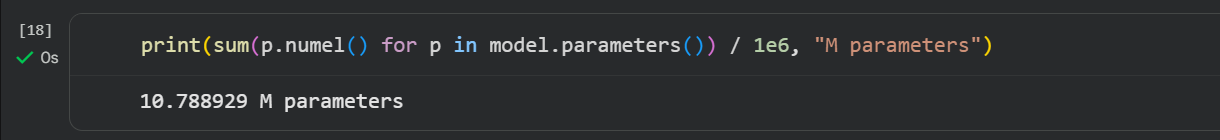

## 🧠 Key Insights

| Concept                  | Explanation                                                       |
| ------------------------- | ----------------------------------------------------------------- |
| **Causal Masking**        | Ensures the model predicts the next token only from past tokens.  |
| **Residual Connections**  | Preserve information and help gradients flow efficiently.         |
| **Layer Normalization**   | Stabilizes learning across layers.                                |
| **Autoregressive Training** | Model predicts the next token sequentially (like GPT-2).        |
| **Embeddings + Attention** | Allow the model to learn meaning and context jointly.            |

---

## 📚 Summary

✅ You now have a **complete mini-GPT model** with:

- Transformer-based **self-attention architecture**  
- Custom **tokenizer and data pipeline**  
- **End-to-end training** and **text generation**

Even though this version is **small**, it captures the **core principles** behind large-scale models like  
**GPT-2**, **GPT-3**, and **GPT-4** — only **scaled down for simplicity and learning**.


# ✨ Wrapping Up

And that’s it — we’ve successfully **built and trained a working GPT-like model from scratch**! 🚀  

Through this notebook, I aimed to:
- Reinforce the **core transformer concepts**
- Show how **attention and tokenization** truly power text generation
- Inspire learners to **build, not just use**, large language models 💡  

---

### 💬 **Next Steps**
If you’d like to take this further:
- Train on larger datasets like **Wikipedia** or **BooksCorpus**
- Try **Byte Pair Encoding (BPE)** for smarter tokenization
- Experiment with **learning rate schedules** and **model checkpointing**
- Or even extend it into a **chatbot interface** using LangChain or Streamlit 🤖  

---

### 🌟 **Connect & Collaborate**
I regularly share AI, NLP, and GenAI notebooks here to make advanced topics **simple and practical**.  
If you found this helpful — **drop a comment, share your thoughts, or connect with me on LinkedIn** 💬  

> “Understanding builds confidence, and confidence builds innovation.” — Let’s keep learning and creating.  
